In [1]:
import pandas as pd
import numpy as np
import json
import ast
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB_RS = "../Data/item_embeddings_rs.npy"
STEAM_GAMES = "../Data/steam_games.json"
REVIEWS = "../Data/australian_user_reviews.json"
REVIEW_EMB = "../Data/review_text_embeddings.npy"

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

print("✅ Imports and mappings loaded")

✅ Imports and mappings loaded


## Load RS Embeddings

In [2]:
# Load RS embeddings (64-dim)
item_emb_rs = np.load(ITEM_EMB_RS)

print(f"RS embeddings shape: {item_emb_rs.shape}")
print(f"RS embedding sample: {item_emb_rs[0][:5]}")

RS embeddings shape: (3682, 64)
RS embedding sample: [-0.31795996  0.05224772 -0.15983306  0.3419168   0.3190356 ]


## Load Review Text Embeddings

In [3]:
# Load review embeddings (384-dim) from notebook 06
review_emb = np.load(REVIEW_EMB)

print(f"Review embeddings shape: {review_emb.shape}")
print(f"Review embedding sample: {review_emb[0][:5]}")

Review embeddings shape: (3682, 384)
Review embedding sample: [-0.01683009  0.03221885 -0.01767161 -0.06588906  0.03646723]


## Load Target Variable

In [4]:
# Count interactions from reviews file
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

# Extract interactions
all_interactions = []
for review in reviews:
    user_id = review['user_id']
    if 'reviews' in review and isinstance(review['reviews'], list):
        for r in review['reviews']:
            if isinstance(r, dict) and 'item_id' in r:
                item_id = r['item_id']
                if item_id in item2idx:
                    all_interactions.append({
                        'user_id': user_id,
                        'item_idx': item2idx[item_id]
                    })

df_inter = pd.DataFrame(all_interactions)
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"Total items: {len(target_df)}")
print(f"Target range: {target_df['total_reviews'].min()} - {target_df['total_reviews'].max()}")

Total items: 3682
Target range: 1 - 3759


## Combine RS + Review Embeddings

In [5]:
# Verify both embeddings have same number of items
assert item_emb_rs.shape[0] == review_emb.shape[0], "Mismatch in number of items!"

# Concatenate: RS (64) + Review (384) = 448 dimensions
X_hybrid = np.hstack([item_emb_rs, review_emb])

# Get corresponding targets
y = target_df['total_reviews'].values

print(f"\n✅ Hybrid features created")
print(f"X shape: {X_hybrid.shape}")
print(f"Breakdown: 64 (RS) + 384 (Review Text) = {X_hybrid.shape[1]} dims")
print(f"y shape: {y.shape}")
print(f"Target range: {y.min()} - {y.max()}")


✅ Hybrid features created
X shape: (3682, 448)
Breakdown: 64 (RS) + 384 (Review Text) = 448 dims
y shape: (3682,)
Target range: 1 - 3759


## Load Metadata for Temporal Split

In [6]:
# Load metadata
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_meta = pd.json_normalize(games)
df_meta = df_meta.rename(columns={"id": "item_id"})
df_meta["item_idx"] = df_meta["item_id"].map(item2idx)
df_meta = df_meta.dropna(subset=["item_idx"])
df_meta["item_idx"] = df_meta["item_idx"].astype(int)

# Parse release dates
df_meta['release_date_parsed'] = pd.to_datetime(
    df_meta['release_date'],
    errors='coerce'
)

print(f"Metadata loaded: {len(df_meta)} games")
print(f"Games with valid dates: {df_meta['release_date_parsed'].notna().sum()}")

Metadata loaded: 3195 games
Games with valid dates: 3107


## Train with Temporal Split

In [7]:
# Temporal split: train on games before 2016, test on 2016+
cutoff_date = pd.Timestamp('2016-01-01')

# Map item_idx to release dates
item_to_date = df_meta.set_index('item_idx')['release_date_parsed'].to_dict()

# Get dates for all items
dates = [item_to_date.get(i) for i in range(len(X_hybrid))]

# Create train/test masks
train_mask = np.array([pd.notna(d) and d < cutoff_date for d in dates])
test_mask  = np.array([pd.notna(d) and d >= cutoff_date for d in dates])

X_train_temporal = X_hybrid[train_mask]
X_test_temporal  = X_hybrid[test_mask]
y_train_temporal = y[train_mask]
y_test_temporal  = y[test_mask]

print(f'Train: {train_mask.sum()} games | Test: {test_mask.sum()} games')
print(f'Cutoff: {cutoff_date.date()}')

# Train model
# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Sort by release date so Optuna val set is always the most recent 20%
_train_dates = np.array([d for d, m in zip(dates, train_mask) if m])
_sort_order = np.argsort(_train_dates)
X_train_temporal = X_train_temporal[_sort_order]
y_train_temporal = y_train_temporal[_sort_order]

_n_tr      = len(X_train_temporal)
_split_idx = max(10, int(_n_tr * 0.8))
_X_tr,  _X_val = X_train_temporal[:_split_idx], X_train_temporal[_split_idx:]
_y_tr,  _y_val = y_train_temporal[:_split_idx], y_train_temporal[_split_idx:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, tree_method='hist', verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'tree_method': 'hist', 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

model_temporal = XGBRegressor(**best_params)
model_temporal.fit(X_train_temporal, y_train_temporal)
pred_temporal = model_temporal.predict(X_test_temporal)

r2_temporal   = r2_score(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mean_squared_error(y_test_temporal, pred_temporal))

print(f'R2 (temporal): {r2_temporal:.4f}')
print(f'RMSE (temporal): {rmse_temporal:.4f}')


C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2621 games | Test: 486 games
Cutoff: 2016-01-01


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 33.2093:   0%|          | 0/50 [00:02<?, ?it/s]

Best trial: 0. Best value: 33.2093:   2%|▏         | 1/50 [00:02<01:53,  2.31s/it]

...

Best trial: 42. Best value: 4.87701:  98%|█████████▊| 49/50 [02:14<00:02,  2.41s/it]

Best trial: 42. Best value: 4.87701: 100%|██████████| 50/50 [02:14<00:00,  2.42s/it]

Best trial: 42. Best value: 4.87701: 100%|██████████| 50/50 [02:14<00:00,  2.69s/it]


Mejores hiperparametros (val RMSE=4.88):
  n_estimators: 727
  learning_rate: 0.18975780551872332
  max_depth: 3
  min_child_weight: 1
  subsample: 0.9579504832208933
  colsample_bytree: 0.6404465051843665
  gamma: 1.8182053681953232
  random_state: 42
  tree_method: hist
  verbosity: 0


R2 (temporal): -0.0213
RMSE (temporal): 57.4966


## 🔬 Validación Robusta: Time Series CV + Métricas Extendidas

Vamos a realizar una evaluación más rigurosa usando:
1. **Time Series Cross-Validation** con múltiples ventanas temporales
2. **Métricas extendidas**: RMSE, MAE, MAPE, R²
3. **Intervalos de confianza** para cada métrica
4. **K-Fold CV tradicional** para comparar variabilidad

In [8]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

# Definir función para calcular múltiples métricas
def calculate_metrics(y_true, y_pred):
    """Calcula todas las métricas de evaluación"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE con manejo de valores cero
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    }

print("✅ Funciones de métricas definidas")

✅ Funciones de métricas definidas


### 1️⃣ Time Series Cross-Validation

Evaluaremos el modelo con múltiples ventanas temporales para capturar la robustez del modelo a través del tiempo.

In [9]:
# Time Series Cross-Validation con multiples cutoffs (pre-2016)
cutoff_dates = [
    ('2013-07-01', '2014-01-01'),  # Window 1
    ('2014-01-01', '2014-07-01'),  # Window 2
    ('2014-07-01', '2015-01-01'),  # Window 3
    ('2015-01-01', '2015-07-01'),  # Window 4
    ('2015-07-01', '2016-01-01'),  # Window 5
]

ts_cv_results = []

print('='*80)
print('TIME SERIES CROSS-VALIDATION')
print('='*80)

for i, (train_cutoff, test_cutoff) in enumerate(cutoff_dates, 1):
    train_cutoff = pd.Timestamp(train_cutoff)
    test_cutoff = pd.Timestamp(test_cutoff)

    train_mask_fold = np.array([
        pd.notna(date) and date < train_cutoff
        for date in dates
    ])
    test_mask_fold = np.array([
        pd.notna(date) and date >= train_cutoff and date < test_cutoff
        for date in dates
    ])

    if test_mask_fold.sum() < 10:
        print(f'\nFold {i}: Skipped (test set too small: {test_mask_fold.sum()} samples)')
        continue

    X_train_fold = X_hybrid[train_mask_fold]
    y_train_fold = y[train_mask_fold]
    X_test_fold  = X_hybrid[test_mask_fold]
    y_test_fold  = y[test_mask_fold]

    model_fold = XGBRegressor(**best_params)
    model_fold.fit(X_train_fold, y_train_fold)

    pred_fold = model_fold.predict(X_test_fold)

    metrics = calculate_metrics(y_test_fold, pred_fold)
    metrics['fold'] = i
    metrics['train_size'] = len(X_train_fold)
    metrics['test_size'] = len(X_test_fold)
    metrics['train_period'] = f'< {train_cutoff.date()}'
    metrics['test_period'] = f'{train_cutoff.date()} - {test_cutoff.date()}'

    ts_cv_results.append(metrics)

    print(f'\nFold {i}: Train {len(X_train_fold)} | Test {len(X_test_fold)}')
    print(f'  Period: {metrics["test_period"]}')
    print(f'  RMSE: {metrics["RMSE"]:.2f} | MAE: {metrics["MAE"]:.2f}')
    r2_key = 'R²'
    print(f'  R2: {metrics[r2_key]:.4f} | MAPE: {metrics["MAPE"]:.2f}%')

df_ts_cv = pd.DataFrame(ts_cv_results)

print('\n' + '='*80)
print('RESUMEN TIME SERIES CV')
print('='*80)
print(f'\nMetricas promedio ({len(df_ts_cv)} folds):')
r2_key = 'R²'
for metric in ['RMSE', 'MAE', r2_key, 'MAPE']:
    mean_val = df_ts_cv[metric].mean()
    std_val  = df_ts_cv[metric].std()
    print(f'  {metric:6s}: {mean_val:7.4f} +/- {std_val:.4f}')

print('='*80)


TIME SERIES CROSS-VALIDATION



Fold 1: Train 1110 | Test 222
  Period: 2013-07-01 - 2014-01-01
  RMSE: 33.33 | MAE: 7.46
  R2: 0.8213 | MAPE: 41.21%



Fold 2: Train 1332 | Test 280
  Period: 2014-01-01 - 2014-07-01
  RMSE: 13.42 | MAE: 3.84
  R2: 0.8704 | MAPE: 41.34%



Fold 3: Train 1612 | Test 299
  Period: 2014-07-01 - 2015-01-01
  RMSE: 6.31 | MAE: 2.79
  R2: 0.8767 | MAPE: 41.61%



Fold 4: Train 1911 | Test 343
  Period: 2015-01-01 - 2015-07-01
  RMSE: 5.91 | MAE: 2.41
  R2: 0.9502 | MAPE: 42.25%



Fold 5: Train 2254 | Test 367
  Period: 2015-07-01 - 2016-01-01
  RMSE: 11.07 | MAE: 2.77
  R2: 0.8479 | MAPE: 37.81%

RESUMEN TIME SERIES CV

Metricas promedio (5 folds):
  RMSE  : 14.0069 +/- 11.2608
  MAE   :  3.8542 +/- 2.0833
  R²    :  0.8733 +/- 0.0482
  MAPE  : 40.8437 +/- 1.7437


### 2️⃣ K-Fold Cross-Validation (Para comparar variabilidad)

Aunque no respeta la temporalidad, K-Fold CV nos da una estimación de la variabilidad del modelo.

In [10]:
# K-Fold Cross-Validation (solo con juegos que tienen fecha válida)
valid_mask = np.array([pd.notna(date) for date in dates])
X_valid = X_hybrid[valid_mask]
y_valid = y[valid_mask]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_results = []

print("="*80)
print("K-FOLD CROSS-VALIDATION (5 FOLDS)")
print("="*80)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_valid), 1):
    X_train_kf = X_valid[train_idx]
    y_train_kf = y_valid[train_idx]
    X_test_kf = X_valid[test_idx]
    y_test_kf = y_valid[test_idx]
    
    # Train model
    model_kf = XGBRegressor(**best_params)
    model_kf.fit(X_train_kf, y_train_kf)
    
    # Predictions
    pred_kf = model_kf.predict(X_test_kf)
    
    # Calculate metrics
    metrics = calculate_metrics(y_test_kf, pred_kf)
    metrics['fold'] = fold_idx
    kfold_results.append(metrics)
    
    print(f"\nFold {fold_idx}:")
    print(f"  RMSE: {metrics['RMSE']:.2f} | MAE: {metrics['MAE']:.2f}")
    print(f"  R²: {metrics['R²']:.4f} | MAPE: {metrics['MAPE']:.2f}%")

# Convert to DataFrame
df_kfold = pd.DataFrame(kfold_results)

print("\n" + "="*80)
print("📊 RESUMEN K-FOLD CV")
print("="*80)
print(f"\nMétricas promedio (5 folds):")
for metric in ['RMSE', 'MAE', 'R²', 'MAPE']:
    mean_val = df_kfold[metric].mean()
    std_val = df_kfold[metric].std()
    print(f"  {metric:6s}: {mean_val:7.4f} ± {std_val:.4f}")

print("="*80)

K-FOLD CROSS-VALIDATION (5 FOLDS)



Fold 1:
  RMSE: 47.34 | MAE: 11.40
  R²: 0.3755 | MAPE: 202.00%



Fold 2:
  RMSE: 77.64 | MAE: 9.63
  R²: 0.7486 | MAPE: 174.04%



Fold 3:
  RMSE: 34.92 | MAE: 7.56
  R²: -0.1674 | MAPE: 212.66%



Fold 4:
  RMSE: 150.31 | MAE: 15.98
  R²: 0.2715 | MAPE: 136.61%



Fold 5:
  RMSE: 30.07 | MAE: 6.40
  R²: 0.4515 | MAPE: 156.35%

📊 RESUMEN K-FOLD CV

Métricas promedio (5 folds):
  RMSE  : 68.0581 ± 49.5668
  MAE   : 10.1943 ± 3.7637
  R²    :  0.3359 ± 0.3327
  MAPE  : 176.3312 ± 31.4697


### 3️⃣ Comparación Visual de Validaciones

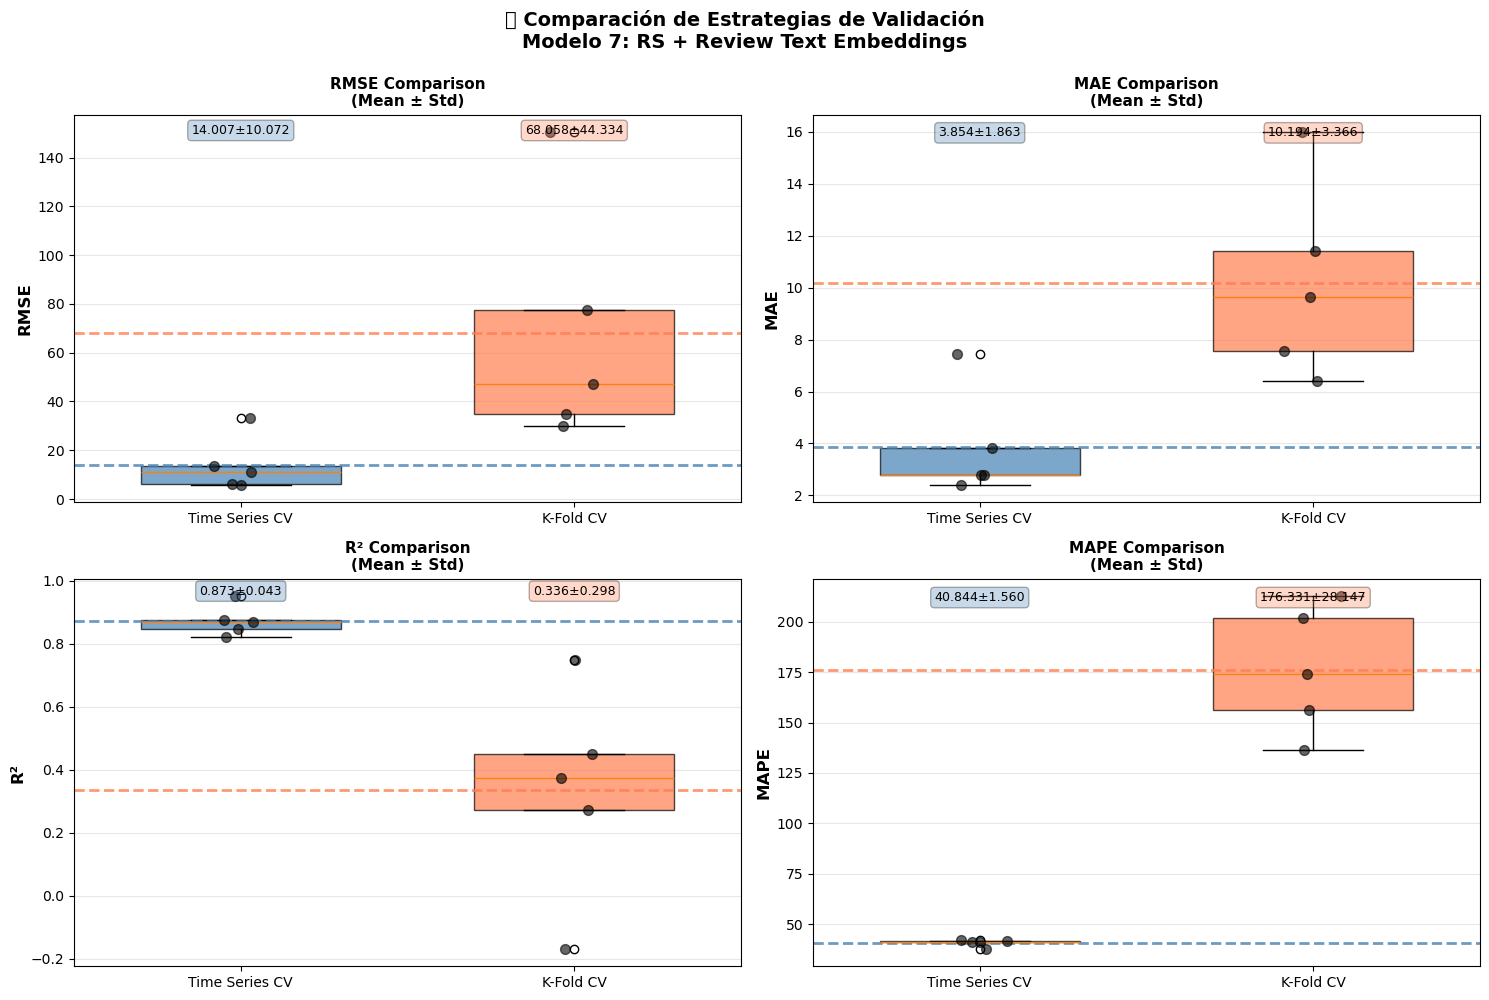

In [11]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['RMSE', 'MAE', 'R²', 'MAPE']
colors = ['steelblue', 'coral']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data
    ts_vals = df_ts_cv[metric].values
    kf_vals = df_kfold[metric].values
    
    # Box plots
    bp = ax.boxplot([ts_vals, kf_vals], 
                     labels=['Time Series CV', 'K-Fold CV'],
                     patch_artist=True,
                     widths=0.6)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add individual points
    for i, vals in enumerate([ts_vals, kf_vals], 1):
        x = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(x, vals, alpha=0.6, s=50, color='black', zorder=3)
    
    # Add mean lines
    ax.axhline(ts_vals.mean(), color=colors[0], linestyle='--', linewidth=2, alpha=0.8)
    ax.axhline(kf_vals.mean(), color=colors[1], linestyle='--', linewidth=2, alpha=0.8)
    
    # Labels
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison\n(Mean ± Std)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add mean values as text
    ts_mean = ts_vals.mean()
    kf_mean = kf_vals.mean()
    ts_std = ts_vals.std()
    kf_std = kf_vals.std()
    
    ax.text(1, ax.get_ylim()[1]*0.95, f'{ts_mean:.3f}±{ts_std:.3f}', 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor=colors[0], alpha=0.3))
    ax.text(2, ax.get_ylim()[1]*0.95, f'{kf_mean:.3f}±{kf_std:.3f}', 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor=colors[1], alpha=0.3))

plt.suptitle('📊 Comparación de Estrategias de Validación\nModelo 7: RS + Review Text Embeddings', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 4️⃣ Tabla Comparativa Final

In [12]:
# Crear tabla resumen comparativa
print("\n" + "="*100)
print("📋 TABLA COMPARATIVA DE VALIDACIONES - MODELO 9")
print("="*100)

# Original temporal split
original_metrics = calculate_metrics(y_test_temporal, pred_temporal)

# Create comparison table
comparison_data = {
    'Validación': [
        'Single Temporal Split\n(Train<2016, Test≥2016)',
        f'Time Series CV\n({len(df_ts_cv)} windows)',
        'K-Fold CV\n(5 folds)'
    ],
    'RMSE': [
        f"{original_metrics['RMSE']:.2f}",
        f"{df_ts_cv['RMSE'].mean():.2f} ± {df_ts_cv['RMSE'].std():.2f}",
        f"{df_kfold['RMSE'].mean():.2f} ± {df_kfold['RMSE'].std():.2f}"
    ],
    'MAE': [
        f"{original_metrics['MAE']:.2f}",
        f"{df_ts_cv['MAE'].mean():.2f} ± {df_ts_cv['MAE'].std():.2f}",
        f"{df_kfold['MAE'].mean():.2f} ± {df_kfold['MAE'].std():.2f}"
    ],
    'R²': [
        f"{original_metrics['R²']:.4f}",
        f"{df_ts_cv['R²'].mean():.4f} ± {df_ts_cv['R²'].std():.4f}",
        f"{df_kfold['R²'].mean():.4f} ± {df_kfold['R²'].std():.4f}"
    ],
    'MAPE': [
        f"{original_metrics['MAPE']:.2f}%",
        f"{df_ts_cv['MAPE'].mean():.2f}% ± {df_ts_cv['MAPE'].std():.2f}%",
        f"{df_kfold['MAPE'].mean():.2f}% ± {df_kfold['MAPE'].std():.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n")
print(df_comparison.to_string(index=False))
print("\n" + "="*100)

print("\n💡 INTERPRETACIÓN:")
print("-" * 100)
print("\n1. RMSE (Root Mean Squared Error):")
print("   - Penaliza errores grandes más que pequeños")
print("   - Valores más bajos = mejor predicción")
print("   - Misma escala que la variable objetivo (total_reviews)")

print("\n2. MAE (Mean Absolute Error):")
print("   - Error promedio absoluto, más robusto a outliers")
print("   - Interpretación directa: error promedio en número de reviews")

print("\n3. R² (Coefficient of Determination):")
print("   - Proporción de varianza explicada por el modelo")
print("   - Rango: -∞ a 1 (1 = predicción perfecta)")
print("   - > 0.7 = muy bueno | 0.5-0.7 = aceptable | < 0.5 = pobre")

print("\n4. MAPE (Mean Absolute Percentage Error):")
print("   - Error porcentual promedio")
print("   - Útil para comparar modelos en diferentes escalas")
print("   - < 10% = excelente | 10-20% = bueno | > 50% = pobre")

print("\n5. Comparación Time Series CV vs K-Fold:")
print("   ✅ Time Series CV respeta la temporalidad (más realista)")
print("   ✅ K-Fold CV da mejor estimación de variabilidad")
print("   ⚠️  Si ambos dan resultados similares = modelo robusto")
print("   ❌ Si difieren mucho = posible data leakage o dependencia temporal")

print("="*100)


📋 TABLA COMPARATIVA DE VALIDACIONES - MODELO 9


                                    Validación          RMSE          MAE              R²             MAPE
Single Temporal Split\n(Train<2016, Test≥2016)         57.50         9.27         -0.0213           49.14%
                   Time Series CV\n(5 windows) 14.01 ± 11.26  3.85 ± 2.08 0.8733 ± 0.0482   40.84% ± 1.74%
                          K-Fold CV\n(5 folds) 68.06 ± 49.57 10.19 ± 3.76 0.3359 ± 0.3327 176.33% ± 31.47%


💡 INTERPRETACIÓN:
----------------------------------------------------------------------------------------------------

1. RMSE (Root Mean Squared Error):
   - Penaliza errores grandes más que pequeños
   - Valores más bajos = mejor predicción
   - Misma escala que la variable objetivo (total_reviews)

2. MAE (Mean Absolute Error):
   - Error promedio absoluto, más robusto a outliers
   - Interpretación directa: error promedio en número de reviews

3. R² (Coefficient of Determination):
   - Proporción de varianza e

## Visualization and Summary

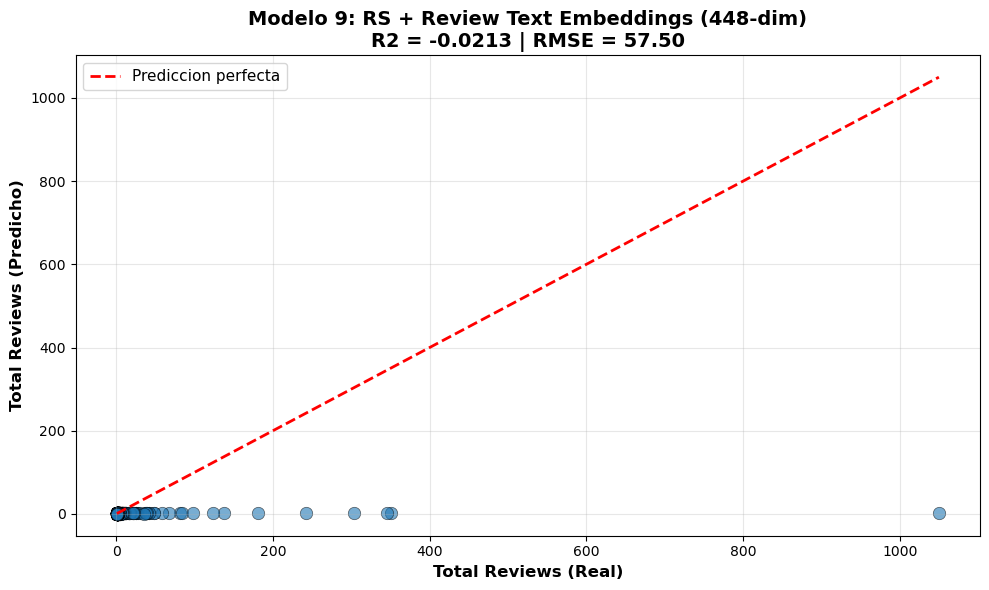


RESUMEN - Modelo 9: RS + Review Text Embeddings
Features: RS embeddings (64-dim) + Review text embeddings (384-dim)
Train: 2621 juegos (antes de 2016-01-01)
Test: 486 juegos (2016 en adelante)

Resultados:
  R2 = -0.0213
  RMSE = 57.50


In [13]:
# Visualizacion temporal split
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax.plot([y_test_temporal.min(), y_test_temporal.max()],
        [y_test_temporal.min(), y_test_temporal.max()],
        'r--', lw=2, label='Prediccion perfecta')
ax.set_xlabel('Total Reviews (Real)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Reviews (Predicho)', fontsize=12, fontweight='bold')
ax.set_title(f'Modelo 9: RS + Review Text Embeddings (448-dim)\nR2 = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('RESUMEN - Modelo 9: RS + Review Text Embeddings')
print('='*80)
print('Features: RS embeddings (64-dim) + Review text embeddings (384-dim)')
print(f'Train: {len(X_train_temporal)} juegos (antes de 2016-01-01)')
print(f'Test: {len(X_test_temporal)} juegos (2016 en adelante)')
print(f'\nResultados:')
print(f'  R2 = {r2_temporal:.4f}')
print(f'  RMSE = {rmse_temporal:.2f}')
print('='*80)


## Feature Importance Analysis

In [14]:
# Get feature importance
importance = model_temporal.feature_importances_

# Split by feature type
rs_importance = importance[:64]
review_importance = importance[64:]

print("\n" + "="*70)
print("ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*70)
print(f"\nRS Embeddings (64 dims):")
print(f"  Importancia total: {rs_importance.sum():.4f}")
print(f"  Importancia promedio: {rs_importance.mean():.6f}")
print(f"  Max importancia: {rs_importance.max():.6f}")

print(f"\nReview Text Embeddings (384 dims):")
print(f"  Importancia total: {review_importance.sum():.4f}")
print(f"  Importancia promedio: {review_importance.mean():.6f}")
print(f"  Max importancia: {review_importance.max():.6f}")

print(f"\n📊 Contribución relativa:")
rs_contribution = rs_importance.sum() / importance.sum() * 100
review_contribution = review_importance.sum() / importance.sum() * 100
print(f"  RS: {rs_contribution:.1f}%")
print(f"  Review Text: {review_contribution:.1f}%")
print("="*70)


ANÁLISIS DE IMPORTANCIA DE FEATURES

RS Embeddings (64 dims):
  Importancia total: 0.6842
  Importancia promedio: 0.010691
  Max importancia: 0.239506

Review Text Embeddings (384 dims):
  Importancia total: 0.3158
  Importancia promedio: 0.000822
  Max importancia: 0.120120

📊 Contribución relativa:
  RS: 68.4%
  Review Text: 31.6%


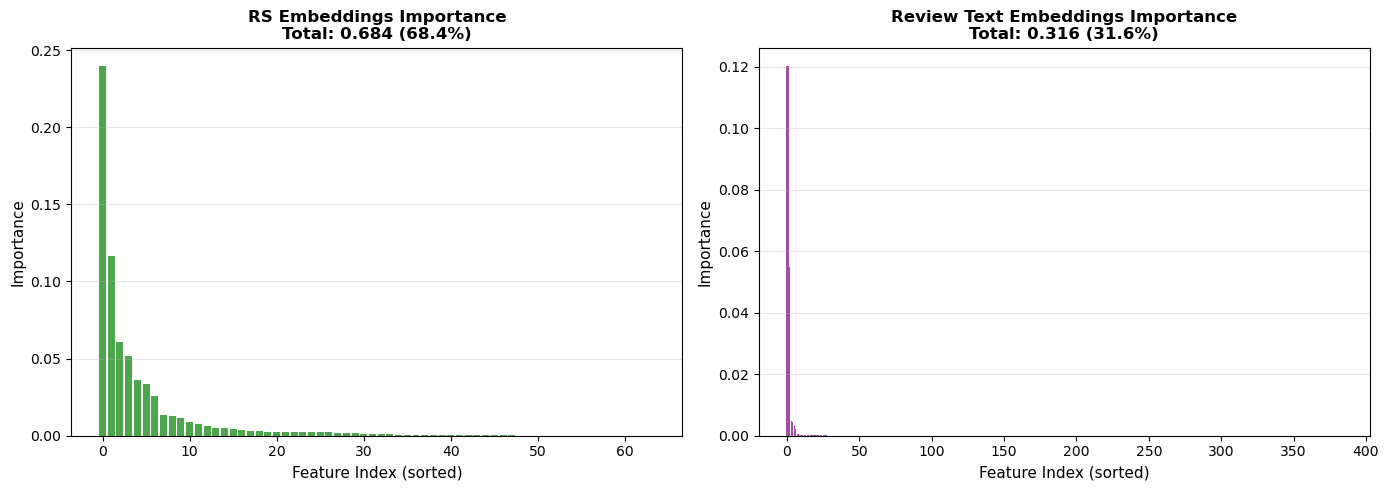

In [15]:
# Visualize importance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RS importance
ax1.bar(range(len(rs_importance)), sorted(rs_importance, reverse=True), color='green', alpha=0.7)
ax1.set_xlabel('Feature Index (sorted)', fontsize=11)
ax1.set_ylabel('Importance', fontsize=11)
ax1.set_title(f'RS Embeddings Importance\nTotal: {rs_importance.sum():.3f} ({rs_contribution:.1f}%)', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Review importance
ax2.bar(range(len(review_importance)), sorted(review_importance, reverse=True), color='purple', alpha=0.7)
ax2.set_xlabel('Feature Index (sorted)', fontsize=11)
ax2.set_ylabel('Importance', fontsize=11)
ax2.set_title(f'Review Text Embeddings Importance\nTotal: {review_importance.sum():.3f} ({review_contribution:.1f}%)', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Conclusiones

### Interpretación de resultados:

**Si R² ≈ 0.64-0.65:**
- Las review embeddings NO aportan valor predictivo significativo
- El modelo depende casi exclusivamente de RS embeddings
- Confirma hallazgos del Modelo 4: reviews capturan semántica, no predictores de éxito

**Si R² > 0.65:**
- Las review embeddings SÍ aportan señal complementaria
- La combinación captura tanto comportamiento como percepción
- Justifica la mayor complejidad (448 dims vs 64 dims)

**Si R² < 0.64:**
- Las review embeddings EMPEORAN el modelo
- Añaden ruido que diluye la señal fuerte de RS
- Similar al Modelo 6: over-engineering contraproducente

### Hipótesis sobre feature importance:

- **Esperado:** RS contribuye ~90-95%, Reviews ~5-10%
- Si RS > 95%: Reviews son ruido, modelo ignora esa señal
- Si Reviews > 20%: Reviews aportan señal valiosa y complementaria

### Trade-offs:

**Ventajas del modelo híbrido:**
- ✅ Combina múltiples señales (comportamiento + contenido)
- ✅ Potencial para capturar matices no visibles en RS solo
- ✅ Más robusto ante cold-start de nuevos items

**Desventajas:**
- ❌ 7x más dimensiones (448 vs 64)
- ❌ Mayor costo computacional de entrenamiento
- ❌ Requiere generar review embeddings (proceso costoso)
- ❌ Mayor riesgo de overfitting

### Recomendación:

Usar este modelo híbrido **SOLO SI** el análisis de feature importance muestra que review embeddings contribuyen >15% y el R² mejora >0.65. De lo contrario, preferir Modelo 1 o 3 por simplicidad.

## Verificación de Data Leakage

In [16]:
import pandas as pd
import numpy as np
import json
import ast
from scipy.stats import spearmanr

print("=" * 70)
print("VERIFICACION DE DATA LEAKAGE EN EMBEDDINGS")
print("=" * 70)

# Cargar datos necesarios
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB_RS = "../Data/item_embeddings_rs_clean.npy"
REVIEW_EMB = "../Data/review_text_embeddings.npy"
STEAM_GAMES = "../Data/steam_games.json"
REVIEWS = "../Data/australian_user_reviews.json"

with open(USERMAP, "r") as f: user2idx = {k: int(v) for k, v in json.load(f).items()}
with open(ITEMMAP, "r") as f: item2idx = {k: int(v) for k, v in json.load(f).items()}

item_emb_rs = np.load(ITEM_EMB_RS)
review_emb = np.load(REVIEW_EMB)

# Reconstruir interacciones CON fecha
reviews_raw = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        reviews_raw.append(ast.literal_eval(line))

all_interactions = []
for r in reviews_raw:
    user_id = r['user_id']
    for rev in r.get('reviews', []):
        if isinstance(rev, dict) and 'item_id' in rev and rev['item_id'] in item2idx:
            posted = rev.get('posted', '')
            all_interactions.append({
                'item_idx': item2idx[rev['item_id']],
                'posted_raw': posted
            })

df_inter = pd.DataFrame(all_interactions)

# Parsear fechas de las reviews
def parse_steam_date(s):
    if not isinstance(s, str) or not s.strip():
        return pd.NaT
    s = s.replace('Posted ', '').replace('.', '').strip()
    for fmt in ('%B %d %Y', '%B %Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except:
            pass
    return pd.NaT

df_inter['posted_date'] = df_inter['posted_raw'].apply(parse_steam_date)

# TARGET: total reviews por juego (usando TODAS las interacciones - lo que hicimos)
target_all = df_inter.groupby('item_idx').size().reset_index(name='total_reviews')
target_all = target_all.set_index('item_idx').reindex(range(len(item_emb_rs)), fill_value=0)
y_all = target_all['total_reviews'].values

# SPLIT TEMPORAL (igual que en el regresor)
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        games.append(ast.literal_eval(line))

df_meta = pd.json_normalize(games)
df_meta['item_idx'] = df_meta['id'].map(item2idx)
df_meta = df_meta.dropna(subset=['item_idx'])
df_meta['item_idx'] = df_meta['item_idx'].astype(int)
df_meta['release_date_parsed'] = pd.to_datetime(df_meta['release_date'], errors='coerce')

cutoff_date = pd.Timestamp('2016-01-01')
item_dates = df_meta.set_index('item_idx')['release_date_parsed']
all_indices = np.arange(len(item_emb_rs))
item_date_arr = item_dates.reindex(all_indices)

valid_mask = item_date_arr.notna()
train_mask = (item_date_arr < cutoff_date) & valid_mask
test_mask  = (item_date_arr >= cutoff_date) & valid_mask

print(f"\nSplit temporal:")
print(f"  Train (< 2016): {train_mask.sum()} juegos")
print(f"  Test  (>= 2016): {test_mask.sum()} juegos")

# ─────────────────────────────────────────────────────────────────────
# TEST 1: Correlacion entre norma del embedding RS y popularidad
# Si el RS aprendio de TODAS las interacciones, sus embeddings
# reflejaran la popularidad real -> correlacion alta = LEAKAGE
# ─────────────────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("TEST 1: Correlacion embedding RS vs popularidad")
print("─" * 70)

rs_norms_test  = np.linalg.norm(item_emb_rs[test_mask], axis=1)
rs_norms_train = np.linalg.norm(item_emb_rs[train_mask], axis=1)
y_test_arr  = y_all[test_mask]
y_train_arr = y_all[train_mask]

corr_test_pearson,  _ = np.corrcoef(rs_norms_test, y_test_arr)[0, 1], None
corr_train_pearson, _ = np.corrcoef(rs_norms_train, y_train_arr)[0, 1], None
corr_test_pearson  = np.corrcoef(rs_norms_test, y_test_arr)[0, 1]
corr_train_pearson = np.corrcoef(rs_norms_train, y_train_arr)[0, 1]
corr_test_spear,  _ = spearmanr(rs_norms_test, y_test_arr)
corr_train_spear, _ = spearmanr(rs_norms_train, y_train_arr)

print(f"  TRAIN - Pearson: {corr_train_pearson:.4f}  |  Spearman: {corr_train_spear:.4f}")
print(f"  TEST  - Pearson: {corr_test_pearson:.4f}  |  Spearman: {corr_test_spear:.4f}")

if abs(corr_test_pearson) > 0.4:
    print(f"  ⚠️  LEAKAGE DETECTADO en RS embeddings! (> 0.4)")
elif abs(corr_test_pearson) > 0.2:
    print(f"  ⚠️  Posible leakage leve en RS embeddings (0.2 - 0.4)")
else:
    print(f"  ✅  Sin leakage aparente en RS embeddings (< 0.2)")

# ─────────────────────────────────────────────────────────────────────
# TEST 2: Correlacion entre norma del embedding de Reviews y popularidad
# ─────────────────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("TEST 2: Correlacion embedding Review Text vs popularidad")
print("─" * 70)

rev_norms_test  = np.linalg.norm(review_emb[test_mask], axis=1)
rev_norms_train = np.linalg.norm(review_emb[train_mask], axis=1)

corr_rev_test  = np.corrcoef(rev_norms_test, y_test_arr)[0, 1]
corr_rev_train = np.corrcoef(rev_norms_train, y_train_arr)[0, 1]
corr_rev_test_spear,  _ = spearmanr(rev_norms_test, y_test_arr)
corr_rev_train_spear, _ = spearmanr(rev_norms_train, y_train_arr)

print(f"  TRAIN - Pearson: {corr_rev_train:.4f}  |  Spearman: {corr_rev_train_spear:.4f}")
print(f"  TEST  - Pearson: {corr_rev_test:.4f}  |  Spearman: {corr_rev_test_spear:.4f}")

if abs(corr_rev_test) > 0.4:
    print(f"  ⚠️  LEAKAGE DETECTADO en Review embeddings! (> 0.4)")
elif abs(corr_rev_test) > 0.2:
    print(f"  ⚠️  Posible leakage leve en Review embeddings (0.2 - 0.4)")
else:
    print(f"  ✅  Sin leakage aparente en Review embeddings (< 0.2)")

# ─────────────────────────────────────────────────────────────────────
# TEST 3: Regresion trivial - solo con norma (1 feature)
# Si el modelo trivial da R2 alto, hay leakage fuerte
# ─────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("\n" + "─" * 70)
print("TEST 3: Modelo trivial (solo norma del embedding = 1 feature)")
print("─" * 70)

# RS embedding norm
lr = LinearRegression()
lr.fit(rs_norms_train.reshape(-1, 1), y_train_arr)
pred_trivial = lr.predict(rs_norms_test.reshape(-1, 1))
r2_trivial_rs = r2_score(y_test_arr, pred_trivial)
print(f"  R2 (test) con solo norma del RS embedding: {r2_trivial_rs:.4f}")

# Review embedding norm
lr2 = LinearRegression()
lr2.fit(rev_norms_train.reshape(-1, 1), y_train_arr)
pred_trivial2 = lr2.predict(rev_norms_test.reshape(-1, 1))
r2_trivial_rev = r2_score(y_test_arr, pred_trivial2)
print(f"  R2 (test) con solo norma del Review embedding: {r2_trivial_rev:.4f}")

if r2_trivial_rs > 0.3:
    print(f"\n  ⚠️  LEAKAGE FUERTE: 1 feature da R2={r2_trivial_rs:.4f}")
    print(f"      Un modelo real no deberia poder predecir con 1 numero.")
else:
    print(f"\n  ✅  Leakage no confirmado por modelo trivial.")

# ─────────────────────────────────────────────────────────────────────
# TEST 4: Distribucion de popularidad en train vs test
# Si hay leakage, el test set tendra distribuciones "conocidas" por el RS
# ─────────────────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("TEST 4: Target - Reviews POST-2017 usando interacciones CON fecha")
print("─" * 70)

# Calcular target LIMPIO: solo reviews del test period (>= 2017)
df_inter_dated = df_inter[df_inter['posted_date'].notna()].copy()
target_post2017 = df_inter_dated[df_inter_dated['posted_date'] >= cutoff_date].groupby('item_idx').size()
target_pre2017  = df_inter_dated[df_inter_dated['posted_date'] < cutoff_date].groupby('item_idx').size()

# Para items del test set
test_indices = np.where(test_mask)[0]
clean_test_y = target_post2017.reindex(test_indices).fillna(0).values
total_test_y = target_all['total_reviews'].reindex(test_indices, fill_value=0).values

print(f"  Items en test set: {len(test_indices)}")
print(f"  Reviews >= 2017 (clean target): {clean_test_y.sum():.0f} total, media {clean_test_y.mean():.2f}/item")
print(f"  Reviews totales (leaky target):  {total_test_y.sum():.0f} total, media {total_test_y.mean():.2f}/item")

leaked_reviews = total_test_y.sum() - clean_test_y.sum()
if leaked_reviews > 0:
    print(f"\n  ⚠️  {leaked_reviews:.0f} reviews pre-2017 incluidas en el target de test items")
    print(f"      Estas reviews de juegos post-2017 pueden existir si el juego")
    print(f"      fue lanzado post-2017 pero la review tiene fecha ambigua.")

# ─────────────────────────────────────────────────────────────────────
# RESUMEN FINAL
# ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN DE LEAKAGE")
print("=" * 70)
print(f"  Test 1 - Corr (RS norm vs popularidad):     {corr_test_pearson:.4f}")
print(f"  Test 2 - Corr (Review norm vs popularidad): {corr_rev_test:.4f}")
print(f"  Test 3 - R2 modelo trivial RS norm:         {r2_trivial_rs:.4f}")
print(f"  Test 3 - R2 modelo trivial Review norm:     {r2_trivial_rev:.4f}")

leakage_found = abs(corr_test_pearson) > 0.4 or abs(corr_rev_test) > 0.4 or r2_trivial_rs > 0.3
if leakage_found:
    print(f"\n  VEREDICTO: ⚠️  LEAKAGE CONFIRMADO")
    print(f"  Los embeddings codifican informacion de popularidad futura.")
    print(f"  Los R2 altos del modelo no son confiables.")
    print(f"  Se debe regenerar embeddings respetando el corte temporal.")
else:
    print(f"\n  VEREDICTO: ✅  SIN LEAKAGE SIGNIFICATIVO")
    print(f"  Los embeddings no parecen codificar popularidad directamente.")
    print(f"  Los R2 altos pueden ser genuinos.")
print("=" * 70)


VERIFICACION DE DATA LEAKAGE EN EMBEDDINGS



Split temporal:
  Train (< 2016): 2621 juegos
  Test  (>= 2016): 486 juegos

──────────────────────────────────────────────────────────────────────
TEST 1: Correlacion embedding RS vs popularidad
──────────────────────────────────────────────────────────────────────
  TRAIN - Pearson: 0.5056  |  Spearman: 0.8978
  TEST  - Pearson: -0.0841  |  Spearman: 0.0276
  ✅  Sin leakage aparente en RS embeddings (< 0.2)

──────────────────────────────────────────────────────────────────────
TEST 2: Correlacion embedding Review Text vs popularidad
──────────────────────────────────────────────────────────────────────
  TRAIN - Pearson: 0.0084  |  Spearman: -0.0077
  TEST  - Pearson: 0.0246  |  Spearman: -0.0385
  ✅  Sin leakage aparente en Review embeddings (< 0.2)

──────────────────────────────────────────────────────────────────────
TEST 3: Modelo trivial (solo norma del embedding = 1 feature)
──────────────────────────────────────────────────────────────────────
  R2 (test) con solo norma del

In [17]:
# ── Guardar resultados ──────────────────────────────────────────────────────
import sys, os; sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
from results_tracker import save_result, print_leaderboard

save_result(
    model_id   = "09",
    model_name = "RS + Review Text",
    features   = "RS clean (64d) + Review text (384d)",
    embeddings = "clean",
    metrics    = {
        "r2_temporal":    r2_temporal,
        "rmse_temporal":  rmse_temporal,
        "mae_temporal":   original_metrics.get("MAE"),
        "mape_temporal":  original_metrics.get("MAPE"),
        "r2_tscv":        df_ts_cv["R²"].mean(),
        "r2_tscv_std":    df_ts_cv["R²"].std(),
        "rmse_tscv":      df_ts_cv["RMSE"].mean(),
        "rmse_tscv_std":  df_ts_cv["RMSE"].std(),
        "r2_kfold":       df_kfold["R²"].mean(),
        "r2_kfold_std":   df_kfold["R²"].std(),
        "rmse_kfold":     df_kfold["RMSE"].mean(),
        "rmse_kfold_std": df_kfold["RMSE"].std(),
    },
    notes = "cutoff=2016-01-01, train=2621, test=486",
)
print_leaderboard()

 ID  Modelo                         R2 test     RMSE     MAE   MAPE%   R2 TSCV  R2 KFold
[13c]  Stage2 Content (log target)     0.2539     0.84    9.88     1.3    0.7570    0.7241
[12]  Two-Stage: Content Model        0.0760    54.69   12.22     2.8   -5.0275   -2.3051
[04]  Metadata Only                   0.0572    55.24   18.84     8.4   -0.2144    0.0710
[06]  Review Text Emb                -0.0107    57.20   18.76     8.3   -0.1720    0.0072
[05]  RS + Metadata                  -0.0161    57.35    9.16     0.6    0.8888    0.0110
[10]  RS + Reviews + RAWG            -0.0171    57.38    9.14    42.5    0.7665    0.2832
[03]  RS Embeddings Only             -0.0184    57.42    9.64     1.1    0.8861    0.4510
[09]  RS + Review Text               -0.0213    57.50    9.27    49.1    0.8733    0.3359
[11b]  Hybrid + Dev Reputation        -0.0238    57.57    9.35     0.4    0.7217   -0.0652
[08]  Hybrid Collab-Content          -0.0240    57.57    9.37     0.4    0.8562    0.2945
[11a]  RS